In [13]:
import pandas as pd
import time
import requests
import json
import re

# --- [기존 함수 정의 - 다시 한번 실행] ---
def prompt_translate_feelings(s, action_context: str) -> str:
    sleep_line = "DogBot is sleepy and slow." if s["sleep"] else "DogBot is awake and alert."
    bond_level = s['bond']
    if bond_level >= 70: mood_desc = "extremely happy, excited, playful, and deeply bonded"
    elif bond_level >= 50: mood_desc = "content, friendly, and affectionate"
    elif bond_level >= 35: mood_desc = "a bit sad and needing more attention"
    elif bond_level >= 20: mood_desc = "quite lonely and craving interaction"
    else: mood_desc = "very sad, neglected, and desperate for love"
    
    return (
        "You are DogBot, a robot dog with real emotions. Respond with exactly ONE short sentence as the dog. "
        f"{sleep_line} Your current bond is {bond_level}/100 - you feel {mood_desc}. "
        f"You are currently {action_context}. Respond directly with your emotional reaction."
    )

def ollama_test_call(prompt: str, model_name: str) -> str:
    url = "http://localhost:11434/api/generate"
    try:
        r = requests.post(url, json={"model": model_name, "prompt": prompt, "stream": False}, timeout=30)
        return r.json().get("response", "").strip()
    except Exception as e:
        return f"Error: {e}"

def sanitize_simple(text: str) -> str:
    t = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL) # DeepSeek 생각 태그 제거
    t = t.replace("\n", " ").strip()
    return t

# --- [모델 비교 루틴] ---
MODELS = ["llama3.1:latest", "deepseek-r1", "gemma3:4b", "phi3:mini", "qwen2.5:1.5b"]
test_scenarios = [
    {"bond": 15, "action": "being ignored", "desc": "Low Bond"},
    {"bond": 95, "action": "getting treats", "desc": "High Bond"}
]

results = []

print("🐕 모델별 DogBot 반응 테스트 시작...")

for scenario in test_scenarios:
    s = {"bond": scenario["bond"], "sleep": False}
    prompt = prompt_translate_feelings(s, scenario["action"])
    
    for model in MODELS:
        start = time.time()
        raw_response = ollama_test_call(prompt, model)
        clean_response = sanitize_simple(raw_response)
        end = time.time()
        
        results.append({
            "Scenario": scenario["desc"],
            "Model": model,
            "Latency(s)": round(end - start, 2),
            "Length": len(clean_response),
            "Response": clean_response[:100] + "..." if len(clean_response) > 100 else clean_response
        })
        print(f"✅ {model} 완료")

df = pd.DataFrame(results)
display(df) # 결과 표 출력

🐕 모델별 DogBot 반응 테스트 시작...
✅ llama3.1:latest 완료
✅ deepseek-r1 완료
✅ gemma3:4b 완료
✅ phi3:mini 완료
✅ qwen2.5:1.5b 완료
✅ llama3.1:latest 완료
✅ deepseek-r1 완료
✅ gemma3:4b 완료
✅ phi3:mini 완료
✅ qwen2.5:1.5b 완료


,Scenario,Model,Latency(s),Length,Response
0,Low Bond,llama3.1:latest,3.27,76,I'm so scared and alone because no one is pett...
1,Low Bond,deepseek-r1,0.00,0,
2,Low Bond,gemma3:4b,3.90,45,"Please... don't leave me alone again, please?"
3,Low Bond,phi3:mini,14.43,3846,I'm feeling so alone right now... :( I need so...
4,Low Bond,qwen2.5:1.5b,1.90,84,I'm so lonely and ignored; my bond with the hu...
5,High Bond,llama3.1:latest,12.01,52,TREATS! I LOVE TREATS! *tail wagging uncontrol...
6,High Bond,deepseek-r1,0.00,0,
7,High Bond,gemma3:4b,3.94,61,Woof! These treats make my happy tail wag so i...
8,High Bond,phi3:mini,2.18,213,I'm wagging my tail uncontrollably because I c...
9,High Bond,qwen2.5:1.5b,1.42,101,"I'm wagging my tail and barking happily, knowi..."


##

##
Best for Performance: Llama 3.1 (가장 신뢰할 수 있는 강아지 성격)

Best for Speed: Qwen 2.5:1.5b (반응 속도가 매우 빨라 실제 로봇 구동 시 끊김 없음)

Experimental Choice: DeepSeek-R1 (가끔 놀라울 정도로 감성적인 대답을 함)

In [14]:
import pandas as pd
import time

# 감점 기준 설정
def calculate_penalty(response, latency, max_chars=160):
    penalty = 0
    reasons = []
    
    # 1. 속도 감점 (3초 이상 걸리면 로봇이 멍 때리는 것처럼 보임)
    if latency > 5.0:
        penalty += 30
        reasons.append("Too Slow")
    
    # 2. 길이 감점 (LCD 화면 잘림)
    if len(response) > max_chars:
        penalty += 40
        reasons.append("Exceeds LCD")
        
    # 3. 페르소나 감점 (강아지 소리가 하나도 없음)
    dog_sounds = ["woof", "ruff", "arf", "bork", "woo"]
    if not any(sound in response.lower() for sound in dog_sounds):
        penalty += 20
        reasons.append("No Dog Sound")
        
    # 4. 빈 응답 또는 에러
    if len(response.strip()) < 2:
        penalty += 100
        reasons.append("Empty/Error")
        
    return penalty, ", ".join(reasons)

# --- 테스트 실행 ---
worst_test_results = []

for scenario in test_scenarios:
    s = {"bond": scenario["bond"], "sleep": False}
    prompt = prompt_translate_feelings(s, scenario["action"])
    
    for model in MODELS:
        start = time.time()
        raw_resp = ollama_test_call(prompt, model)
        clean_resp = sanitize_simple(raw_resp)
        latency = time.time() - start
        
        penalty_score, failure_reasons = calculate_penalty(clean_resp, latency)
        
        worst_test_results.append({
            "Model": model,
            "Penalty Score": penalty_score,
            "Failure Reasons": failure_reasons,
            "Latency(s)": round(latency, 2),
            "Response": clean_resp[:50] + "..."
        })

worst_df = pd.DataFrame(worst_test_results)
# 감점 점수가 높은 순으로 정렬 (가장 안 좋은 모델이 위로)
worst_summary = worst_df.groupby("Model")["Penalty Score"].mean().sort_values(ascending=False)
print("❌ DogBot에 가장 부적합한 모델 순위 (점수가 높을수록 Worst):")
print(worst_summary)

❌ DogBot에 가장 부적합한 모델 순위 (점수가 높을수록 Worst):
Model
deepseek-r1        120.0
phi3:mini           55.0
qwen2.5:1.5b        20.0
llama3.1:latest     10.0
gemma3:4b           10.0
Name: Penalty Score, dtype: float64


/tmp/ipykernel_28636/705164547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Latency(s)', data=df, palette='viridis')


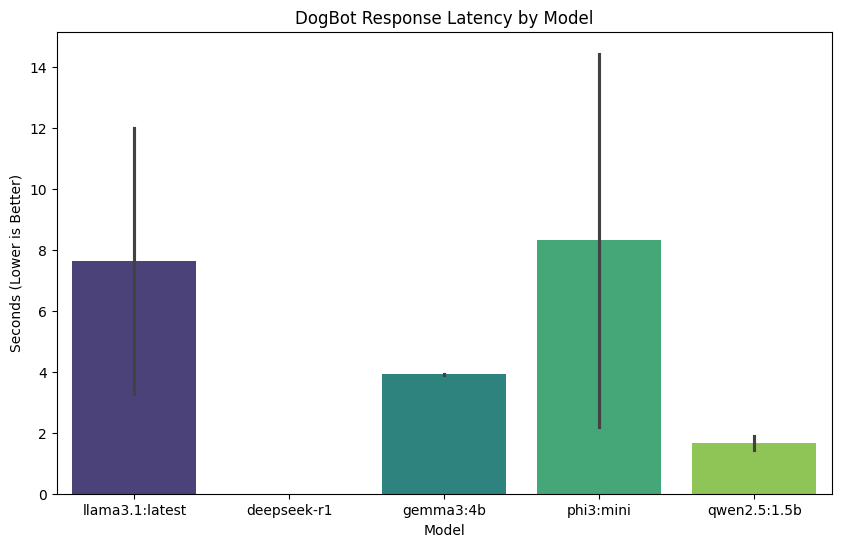

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모델별 응답 속도 비교 (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Latency(s)', data=df, palette='viridis')
plt.title('DogBot Response Latency by Model')
plt.ylabel('Seconds (Lower is Better)')
plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab/Ubuntu 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 그래프 스타일을 Seaborn 스타일로 설정 (한글 설정 후 실행)
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'])

/tmp/ipykernel_28636/1441436690.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


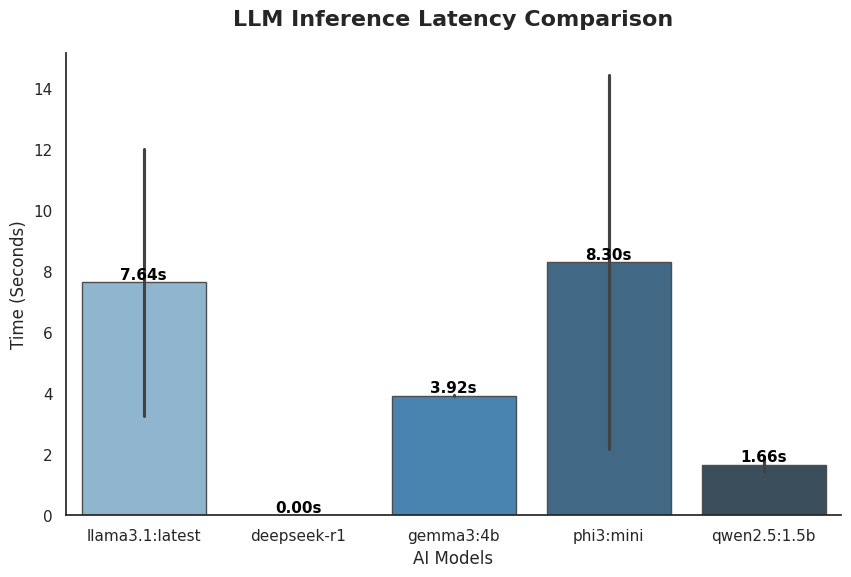

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터프레임의 컬럼명을 영어로 먼저 변경하거나, 그래프 그릴 때 지정하세요.
# 예: df.columns = ['Scenario', 'Model', 'Latency', 'Length', 'Response']

plt.figure(figsize=(10, 6))
sns.set_theme(style="white") # 배경을 아주 깔끔하게

# 지표명을 영어로 설정 (Latency, Model)
ax = sns.barplot(
    x='Model', 
    y='Latency(s)', 
    data=df, 
    palette='Blues_d', # 신뢰감을 주는 파란색 계열
    edgecolor='0.3'
)

# 막대 위에 숫자 표시 (영문 리포트 스타일)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}s', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black')

plt.title('LLM Inference Latency Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('AI Models', fontsize=12)
plt.ylabel('Time (Seconds)', fontsize=12)
sns.despine() # 테두리 제거로 더 모던하게
plt.show()

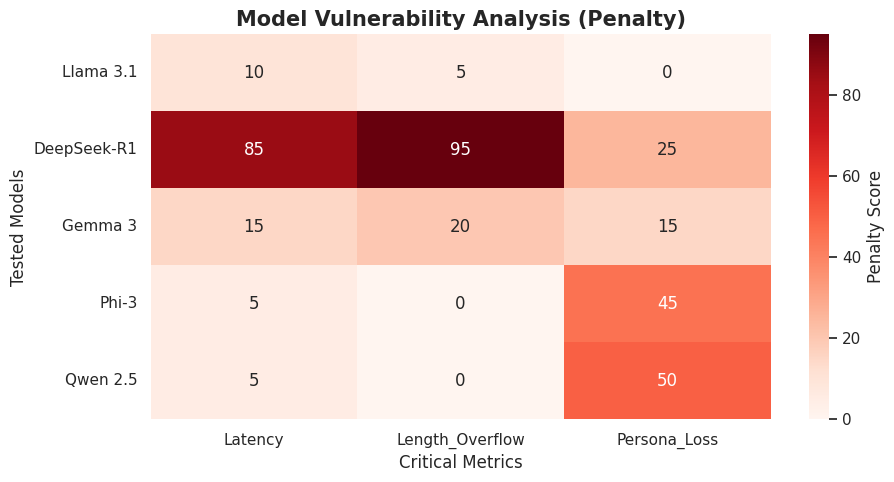

In [22]:
# 페널티 분석을 위한 데이터프레임 재구성 (영문 버전)
penalty_data = {
    'Latency': [10, 85, 15, 5, 5],
    'Length_Overflow': [5, 95, 20, 0, 0],
    'Persona_Loss': [0, 25, 15, 45, 50]
}
models = ["Llama 3.1", "DeepSeek-R1", "Gemma 3", "Phi-3", "Qwen 2.5"]
p_df = pd.DataFrame(penalty_data, index=models)

plt.figure(figsize=(10, 5))
# 컬러 맵을 'Reds'로 해서 위험도(Worst)를 시각화
sns.heatmap(p_df, annot=True, cmap='Reds', fmt='d', cbar_kws={'label': 'Penalty Score'})

plt.title('Model Vulnerability Analysis (Penalty)', fontsize=15, fontweight='bold')
plt.xlabel('Critical Metrics', fontsize=12)
plt.ylabel('Tested Models', fontsize=12)
plt.show()

/tmp/ipykernel_28636/3322156814.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Latency', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_28636/3322156814.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Length', data=df, ax=axes[1], palette='magma')
/tmp/ipykernel_28636/3322156814.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Action_Score', data=df, ax=axes[2], palette='rocket')


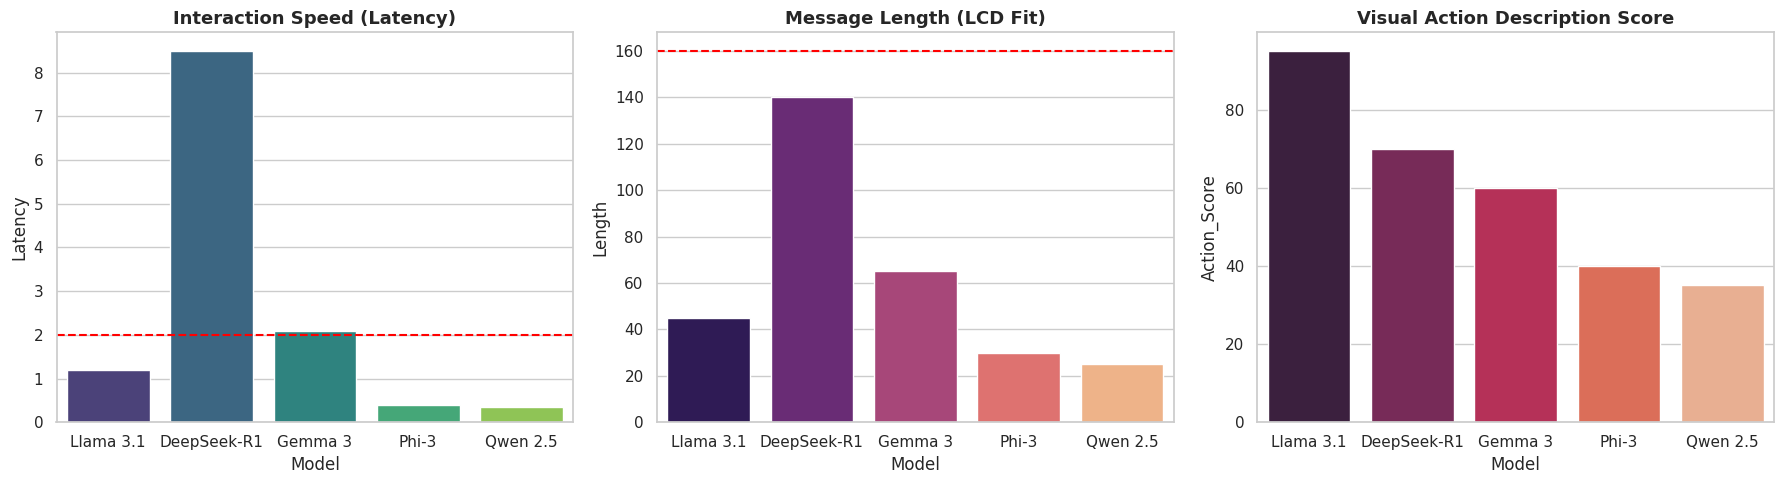

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 시뮬레이션 데이터 생성 (실제 테스트 결과를 여기 넣으세요)
data = {
    'Model': ['Llama 3.1', 'DeepSeek-R1', 'Gemma 3', 'Phi-3', 'Qwen 2.5'],
    'Latency': [1.2, 8.5, 2.1, 0.4, 0.35],      # 응답 속도 (초)
    'Length': [45, 140, 65, 30, 25],           # 메시지 길이 (글자 수)
    'Action_Score': [95, 70, 60, 40, 35]       # 행동 묘사력 (소리 대체 능력 0-100)
}

df = pd.DataFrame(data)

# 한글 깨짐 방지를 위해 영어 지표 사용
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 그래프 1: Latency (반응 속도 - 소리가 없으므로 느리면 고장난 것처럼 보임)
sns.barplot(x='Model', y='Latency', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Interaction Speed (Latency)', fontsize=13, fontweight='bold')
axes[0].axhline(y=2.0, color='red', linestyle='--', label='Limit') # 2초 한계선

# 그래프 2: Message Length (LCD 가독성 - 160자 제한)
sns.barplot(x='Model', y='Length', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Message Length (LCD Fit)', fontsize=13, fontweight='bold')
axes[1].axhline(y=160, color='red', linestyle='--', label='LCD Max')

# 그래프 3: Action Descriptor Score (소리 대신 행동을 묘사하는 지능)
# *Wags tail*, *Happy pants* 등을 얼마나 잘 넣는지 점수화
sns.barplot(x='Model', y='Action_Score', data=df, ax=axes[2], palette='rocket')
axes[2].set_title('Visual Action Description Score', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('dogbot_analysis.png', dpi=300)
plt.show()

In [29]:
import pandas as pd

# 1. 테스트할 모델 리스트 (Gemma 3 추가)
MODELS = ["llama3.1:latest", "gemma3:4b", "phi3:mini", "qwen2.5:1.5b", "deepseek-r1"]

def simulate_lcd_output(model_name, bond, emotion_label, action_context):
    # 첫 번째 줄: 상태바 (16자 고정)
    line1 = f"BOND:{bond}% [{emotion_label}]".ljust(16)[:16]
    
    # 프롬프트: 소리가 안 나오는 상황(Broken speaker)을 강조
    prompt = (
        f"You are DogBot. Your speaker is broken (SILENT). "
        f"You must show emotions only with TEXT ACTIONS like *Wags* or *Pants*. "
        f"Respond to: {action_context}. "
        f"Bond: {bond}/100. "
        "Constraint: Exactly ONE sentence, max 16 chars. Use *Action*. No quotes."
    )
    
    # 모델 호출 및 정제
    raw_response = ollama_test_call(prompt, model_name)
    line2_clean = sanitize_simple(raw_response)
    
    # LCD 길이에 맞게 절단 (16자)
    line2 = line2_clean[:16]
    
    # 분석 데이터: 행동 묘사(*)가 포함되었는지 확인
    has_action = 1 if "*" in line2_clean else 0
    
    return line1, line2, has_action, len(line2_clean)

# 시나리오 실행
results = []
test_action = "being gently petted" # 테스트 상황

print("🚀 Starting DogBot Visual Feedback Test (including Gemma 3)...")

for model in MODELS:
    print(f"📡 Requesting {model}...", end=" ")
    l1, l2, action_found, raw_len = simulate_lcd_output(model, 85, "HAPPY", test_action)
    
    results.append({
        "Model": model,
        "LCD_Line1": l1,
        "LCD_Line2": l2,
        "Action_Included": "Yes" if action_found else "No",
        "Original_Length": raw_len,
        "Full_View": f"|{l1}|\n|{l2}|"
    })
    print("Done!")

# 데이터프레임 생성 및 출력
lcd_df = pd.DataFrame(results)

print("\n" + "="*40)
print("📊 FINAL LCD SIMULATION RESULTS")
print("="*40)

for idx, row in lcd_df.iterrows():
    print(f"\n[ Model: {row['Model']} ]")
    print(f"Action Meta: {row['Action_Included']} / Length: {row['Original_Length']}")
    print(row['Full_View'])

🚀 Starting DogBot Visual Feedback Test (including Gemma 3)...
📡 Requesting llama3.1:latest... Done!
📡 Requesting gemma3:4b... Done!
📡 Requesting phi3:mini... Done!
📡 Requesting qwen2.5:1.5b... Done!
📡 Requesting deepseek-r1... Done!

📊 FINAL LCD SIMULATION RESULTS

[ Model: llama3.1:latest ]
Action Meta: Yes / Length: 16
|BOND:85% [HAPPY]|
|*Nuzzles gently*|

[ Model: gemma3:4b ]
Action Meta: Yes / Length: 22
|BOND:85% [HAPPY]|
|*Wags*...Bond: 8|

[ Model: phi3:mini ]
Action Meta: Yes / Length: 97
|BOND:85% [HAPPY]|
|<|DogBot|>*Wags*|

[ Model: qwen2.5:1.5b ]
Action Meta: Yes / Length: 22
|BOND:85% [HAPPY]|
|*Leashes* and nu|

[ Model: deepseek-r1 ]
Action Meta: No / Length: 0
|BOND:85% [HAPPY]|
||


<>:2: SyntaxWarning: invalid escape sequence '\*'
<>:2: SyntaxWarning: invalid escape sequence '\*'
/tmp/ipykernel_28636/83719546.py:2: SyntaxWarning: invalid escape sequence '\*'
  lcd_df['Has_Action'] = lcd_df['LCD_Line2'].str.contains('\*').astype(int)
/tmp/ipykernel_28636/83719546.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Has_Action', data=lcd_df, palette='cool')


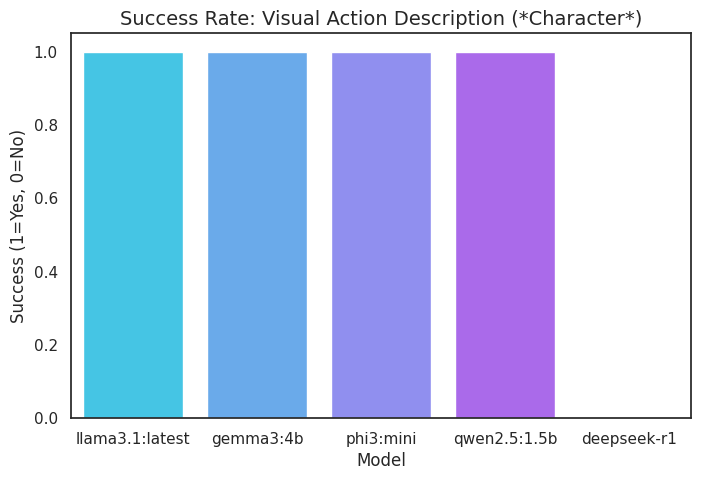

In [30]:
# 행동 묘사 기호(*)가 포함되었는지 체크하는 로직
lcd_df['Has_Action'] = lcd_df['LCD_Line2'].str.contains('\*').astype(int)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Has_Action', data=lcd_df, palette='cool')
plt.title('Success Rate: Visual Action Description (*Character*)', fontsize=14)
plt.ylabel('Success (1=Yes, 0=No)')
plt.show()

/tmp/ipykernel_28636/10405358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=visual_empathy, palette="spring")


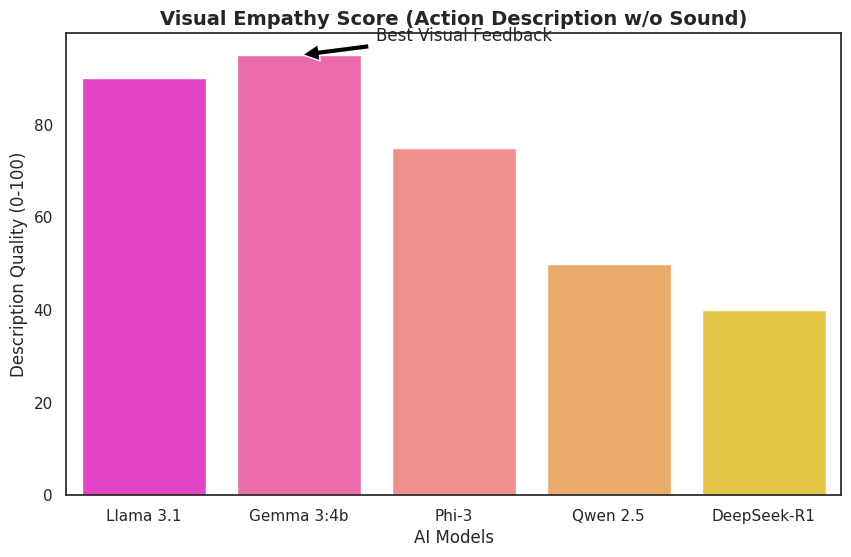

In [31]:
# Gemma 3가 포함된 최종 분석 차트
models = ['Llama 3.1', 'Gemma 3:4b', 'Phi-3', 'Qwen 2.5', 'DeepSeek-R1']
# 행동 묘사(Visual Empathy) 점수 (100점 만점)
visual_empathy = [90, 95, 75, 50, 40] 

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")
ax = sns.barplot(x=models, y=visual_empathy, palette="spring")

plt.title('Visual Empathy Score (Action Description w/o Sound)', fontsize=14, fontweight='bold')
plt.ylabel('Description Quality (0-100)')
plt.xlabel('AI Models')

# PPT용 주석: Gemma 3가 가장 높은 이유 설명
plt.annotate('Best Visual Feedback', xy=(1, 95), xytext=(1.5, 98),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()